In [11]:
import os
import pandas as pd

import glob
import numpy as np

import torch

from model import INNLightningModule
import train

from plottingtools import plot_1d_hist, plot_2d_hist, plot_2d_res_hist
from matplotlib import pyplot as plt
import mplhep as hep
hep.style.use(hep.style.ATLAS)

In [12]:
ckpt_files = glob.glob(f"/root/work/ww-flow_nohl/logs/hww_inn_regressor-lep/log/version_0/checkpoints/*.ckpt")
if not ckpt_files:
    raise FileNotFoundError(f"No checkpoint files found in {ckpt_files}")
ckpt_path = ckpt_files[0]  # Use the first checkpoint found
print(f"Using checkpoint: {ckpt_path}")

Using checkpoint: /root/work/ww-flow_nohl/logs/hww_inn_regressor-lep/log/version_0/checkpoints/reg-epoch=179-val_loss=2.22.ckpt


In [13]:
# Retrieve datamodule used in training
dm, X_stdscalar, Y_stdscalar = train.main(train=False)
# Get the test dataloader
# `dm.setup()` to resample and standardize the data
# with the fix random seed to ensure no-mixing with training data
dm.setup()
test_loader = dm.test_dataloader()

# Load model from checkpoint
model = INNLightningModule.load_from_checkpoint(ckpt_path)
model.eval() # used to inference -> not for training phase

predictions = np.empty([0, dm.X.shape[1]]) # pred ww
predictions_inputs = np.empty([0, dm.Y.shape[1]]) # pred inputs
true_labels = np.empty([0, dm.X.shape[1]]) # true ww
test_features = np.empty([0, dm.Y.shape[1]]) # lvlv
sample_z = np.empty([0, model.hparams.z_dim]) # sampled z
predictions_z = np.empty([0, model.hparams.z_dim]) # predicted z

# Cache scaler parameters as NumPy arrays to avoid torch/NumPy mixed arithmetic warnings
x_scale = np.asarray(X_stdscalar.scale_)
x_mean = np.asarray(X_stdscalar.mean_)
y_scale_8 = np.asarray(Y_stdscalar.scale_[:8])
y_mean_8 = np.asarray(Y_stdscalar.mean_[:8])

# Inference loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
    for batch in test_loader:
        batch_ww, batch_lvlv = batch
        cond = batch_lvlv[:, 8:]  # conditioning variables
        batch_lvlv = batch_lvlv[:, :8]
        cond = cond.to(device)
        batch_ww = batch_ww.to(device)
        batch_lvlv = batch_lvlv.to(device)
        _z_like_tensor = torch.randn(batch_lvlv.shape[0], model.hparams.z_dim, device=device)
        # z_sample = randmultin(_z_like_tensor, device=device)
        z_sample = torch.randn_like(_z_like_tensor) # Gaussian prior
        yz = torch.cat([batch_lvlv.to(device), z_sample.to(device)], dim=1)
        lvlv_pred = model(batch_ww, cond, reverse=False) # the prediction gives the inputs (y, z)
        ww_pred = model(yz, cond, reverse=True)
        z_pred = lvlv_pred[1] # predicted z

        ww_pred_np = ww_pred[:, :model.inn.x_dim].cpu().numpy()
        ww_np = batch_ww.cpu().numpy()
        lvlv_np = batch_lvlv.cpu().numpy()
        lvlv_pred_np = lvlv_pred[0].cpu().numpy() # don't include z

        ww_pred = ww_pred_np * x_scale + x_mean
        ww = ww_np * x_scale + x_mean
        lvlv = lvlv_np * y_scale_8 + y_mean_8
        lvlv_pred = lvlv_pred_np * y_scale_8 + y_mean_8

        # Store results
        predictions = np.append(predictions, ww_pred, axis=0)
        true_labels = np.append(true_labels, ww, axis=0)
        test_features = np.append(test_features[:, :8], lvlv, axis=0)
        predictions_inputs = np.append(predictions_inputs[:, :8], lvlv_pred, axis=0)
        sample_z = np.append(sample_z, z_sample.cpu().numpy(), axis=0)
        predictions_z = np.append(predictions_z, z_pred.cpu().numpy(), axis=0)

print("Inference completed.")
print(f"Test features shape: {test_features.shape}")
print(f"Predictions shape: {predictions.shape}")
print(f"True labels shape: {true_labels.shape}")

Evaluation mode, loading checkpoints...
Training objects shape: (376985, 29)
Target objects shape: (376985, 4)
Removed 117 rows with NaN or infinite values
Using 2 workers in data loading.
Loading model from checkpoint for evaluation... return datamodule
Inference completed.
Test features shape: (3768, 8)
Predictions shape: (3768, 4)
True labels shape: (3768, 4)


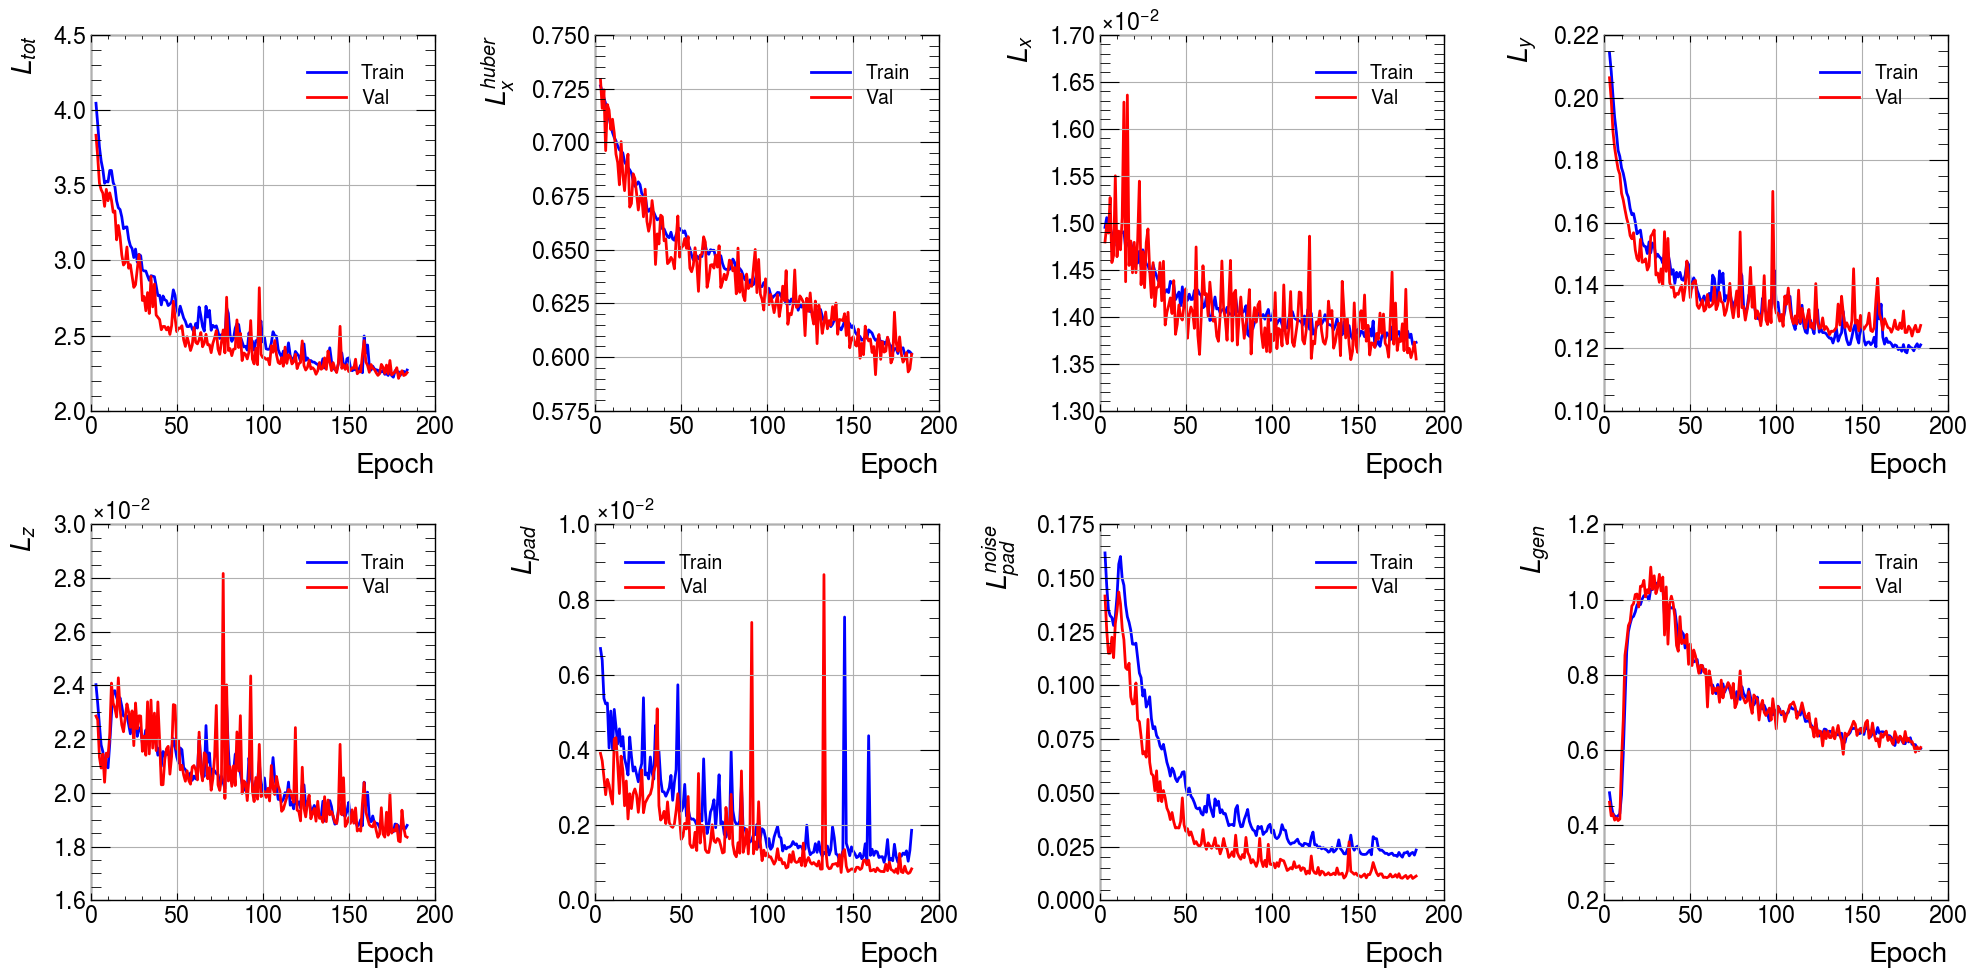


Final Training Losses (Epoch 184):
  Total Loss: 2.270819
  L_x: 0.013727
  L_x_huber: 0.601480
  L_y: 0.121023
  L_z: 0.018788
  L_pad: 0.001861
  L_pad_noise: 0.023378
  L_x_gen: 0.603486

Final Validation Losses:
  Total Loss: 2.254030
  L_x: 0.013551
  L_x_huber: 0.601287
  L_y: 0.127238
  L_z: 0.018348
  L_pad: 0.000834
  L_pad_noise: 0.011265
  L_x_gen: 0.606561


In [14]:
# Find all lightning_logs/version_* directories
log_dirs = glob.glob("logs/hww_inn_regressor-lep/log/version_*")
if not log_dirs:
    print("No logs found.")
else:
    # Select the largest version number (latest run)
    latest_log = max(log_dirs, key=lambda x : int(os.path.basename(x).split("_")[1]))
    metrics_path = os.path.join(latest_log, "metrics.csv")
    if not os.path.exists(metrics_path):
        print(f"No metrics.csv found in {latest_log}")
    else:
        # Read metrics
        df = pd.read_csv(metrics_path)

        # Remove rows with NaN in train_loss or val_loss
        df_clean = df.copy()
        if "train_loss" in df_clean.columns:
            df_clean_train = df_clean[df_clean["train_loss"].notna()]
        if "val_loss" in df_clean.columns:
            df_clean_val = df_clean[df_clean["val_loss"].notna()]

        # Create subplots for better visualization
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        
        # Plot 1: Total Loss
        axes[0, 0].plot(df_clean_train["epoch"][3:], df_clean_train["train_loss"][3:], label="Train", color='blue')
        axes[0, 0].plot(df_clean_val["epoch"][3:], df_clean_val["val_loss"][3:], label="Val", color='red')
        axes[0, 0].set_xlabel("Epoch")
        axes[0, 0].set_ylabel("$L_{tot}$")
        axes[0, 0].legend()
        axes[0, 0].grid(True)

        # Plot 2: L_x_huber (reconstruction loss)
        axes[0, 1].plot(df_clean_train["epoch"][3:], df_clean_train["L_x_huber"][3:], label="Train", color='blue')
        axes[0, 1].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_x_huber"][3:], label="Val", color='red')
        axes[0, 1].set_xlabel("Epoch")
        axes[0, 1].set_ylabel("$L_{x}^{huber}$")
        axes[0, 1].legend()
        axes[0, 1].grid(True)
        
        # Plot 3: L_x (reconstruction loss)
        axes[0, 2].plot(df_clean_train["epoch"][3:], df_clean_train["L_x"][3:], label="Train", color='blue')
        axes[0, 2].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_x"][3:], label="Val", color='red')
        axes[0, 2].set_xlabel("Epoch")
        axes[0, 2].set_ylabel("$L_{x}$")
        axes[0, 2].legend()
        axes[0, 2].grid(True)

        # Plot 3: L_y (reconstruction loss)
        axes[0, 3].plot(df_clean_train["epoch"][3:], df_clean_train["L_y"][3:], label="Train", color='blue')
        axes[0, 3].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_y"][3:], label="Val", color='red')
        axes[0, 3].set_xlabel("Epoch")
        axes[0, 3].set_ylabel("$L_y$")
        axes[0, 3].legend()
        axes[0, 3].grid(True)
        
        # Plot 3: L_z (latent space loss)
        axes[1, 0].plot(df_clean_train["epoch"][3:], df_clean_train["L_z"][3:], label="Train", color='blue')
        axes[1, 0].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_z"][3:], label="Val", color='red')
        axes[1, 0].set_xlabel("Epoch")
        axes[1, 0].set_ylabel("$L_z$")
        axes[1, 0].legend()
        axes[1, 0].grid(True)
        
        # Plot 5: L_pad (padding loss)
        axes[1, 1].plot(df_clean_train["epoch"][3:], df_clean_train["L_pad"][3:], label="Train", color='blue')
        axes[1, 1].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_pad"][3:], label="Val", color='red')
        axes[1, 1].set_xlabel("Epoch")
        axes[1, 1].set_ylabel("$L_{pad}$")
        axes[1, 1].legend()
        axes[1, 1].grid(True)

        # Plot 6: L_pad_noise (input reconstruction loss)
        axes[1, 2].plot(df_clean_train["epoch"][3:], df_clean_train["L_pad_noise"][3:], label="Train", color='blue')
        axes[1, 2].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_pad_noise"][3:], label="Val", color='red')
        axes[1, 2].set_xlabel("Epoch")
        axes[1, 2].set_ylabel("$L_{pad}^{noise}$")
        axes[1, 2].legend()
        axes[1, 2].grid(True)
        
        # Plot 6: L_x_gen (input reconstruction loss)
        axes[1, 3].plot(df_clean_train["epoch"][3:], df_clean_train["L_x_gen"][3:], label="Train", color='blue')
        axes[1, 3].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_x_gen"][3:], label="Val", color='red')
        axes[1, 3].set_xlabel("Epoch")
        axes[1, 3].set_ylabel("$L_{gen}$")
        axes[1, 3].legend()
        axes[1, 3].grid(True)

        plt.tight_layout()
        plt.show()
        
        # Print final loss values for analysis
        print(f"\nFinal Training Losses (Epoch {df_clean_train['epoch'].iloc[-1]}):")
        print(f"  Total Loss: {df_clean_train['train_loss'].iloc[-1]:.6f}")
        print(f"  L_x: {df_clean_train['L_x'].iloc[-1]:.6f}")
        print(f"  L_x_huber: {df_clean_train['L_x_huber'].iloc[-1]:.6f}")
        print(f"  L_y: {df_clean_train['L_y'].iloc[-1]:.6f}")
        print(f"  L_z: {df_clean_train['L_z'].iloc[-1]:.6f}")
        print(f"  L_pad: {df_clean_train['L_pad'].iloc[-1]:.6f}")
        print(f"  L_pad_noise: {df_clean_train['L_pad_noise'].iloc[-1]:.6f}")
        print(f"  L_x_gen: {df_clean_train['L_x_gen'].iloc[-1]:.6f}")
        
        print(f"\nFinal Validation Losses:")
        print(f"  Total Loss: {df_clean_val['val_loss'].iloc[-1]:.6f}") 
        print(f"  L_x: {df_clean_val['val_L_x'].iloc[-1]:.6f}")
        print(f"  L_x_huber: {df_clean_val['val_L_x_huber'].iloc[-1]:.6f}")
        print(f"  L_y: {df_clean_val['val_L_y'].iloc[-1]:.6f}")
        print(f"  L_z: {df_clean_val['val_L_z'].iloc[-1]:.6f}")
        print(f"  L_pad: {df_clean_val['val_L_pad'].iloc[-1]:.6f}")
        print(f"  L_pad_noise: {df_clean_val['val_L_pad_noise'].iloc[-1]:.6f}")
        print(f"  L_x_gen: {df_clean_val['val_L_x_gen'].iloc[-1]:.6f}")

In [15]:
true_lep0_px = test_features[..., 0]
true_lep0_py = test_features[..., 1]
true_lep0_eta = test_features[..., 2]
true_lep0_e = test_features[..., 3]
true_lep1_px = test_features[..., 4]
true_lep1_py = test_features[..., 5]
true_lep1_eta = test_features[..., 6]
true_lep1_e = test_features[..., 7]

pred_lep0_px = predictions_inputs[..., 0]
pred_lep0_py = predictions_inputs[..., 1]
pred_lep0_eta = predictions_inputs[..., 2]
pred_lep0_e = predictions_inputs[..., 3]
pred_lep1_px = predictions_inputs[..., 4]
pred_lep1_py = predictions_inputs[..., 5]
pred_lep1_eta = predictions_inputs[..., 6]
pred_lep1_e = predictions_inputs[..., 7]

true_z = sample_z
pred_z = predictions_z

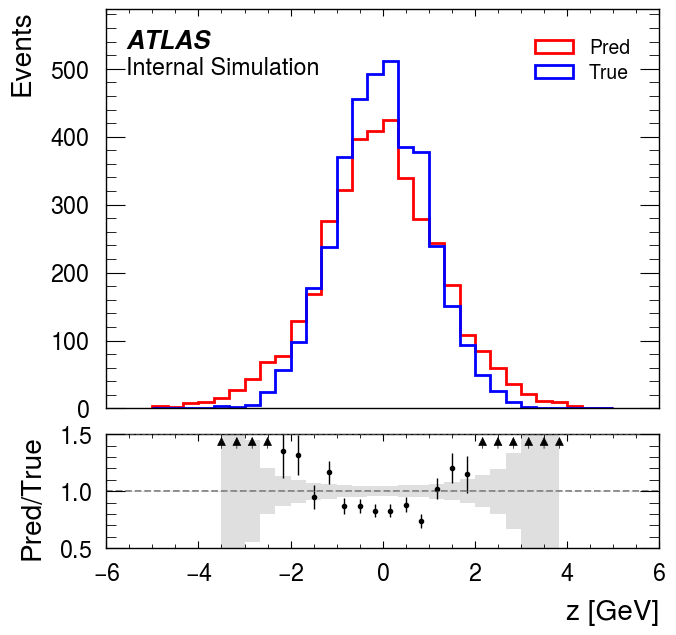

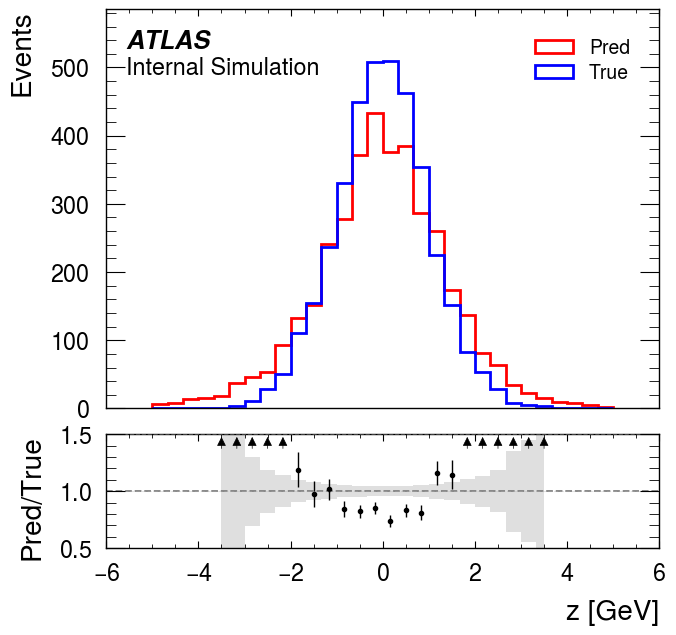

In [16]:
plot_1d_hist(pred_z[..., 0], true_z[..., 0], "z", bins_edges=np.linspace(-5, 5, 31))
plot_1d_hist(pred_z[..., -2], true_z[..., -2], "z", bins_edges=np.linspace(-5, 5, 31))

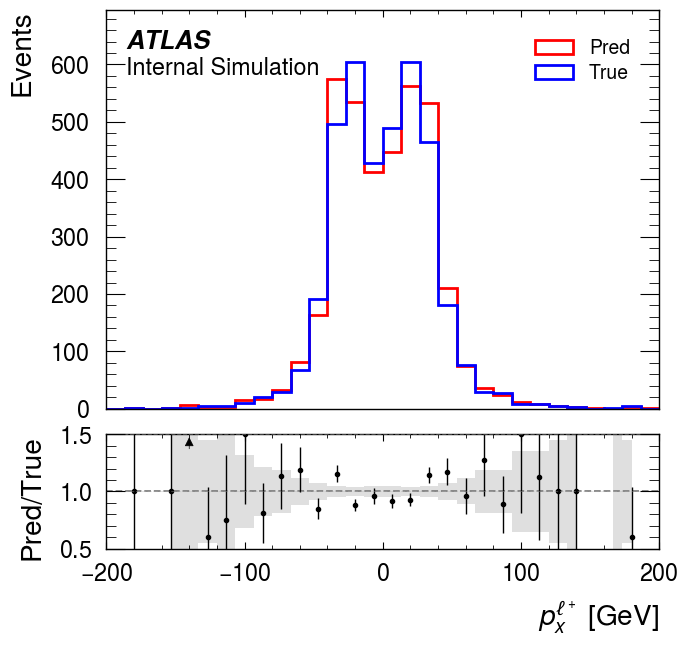

Rel err < 20%: 65.92 %


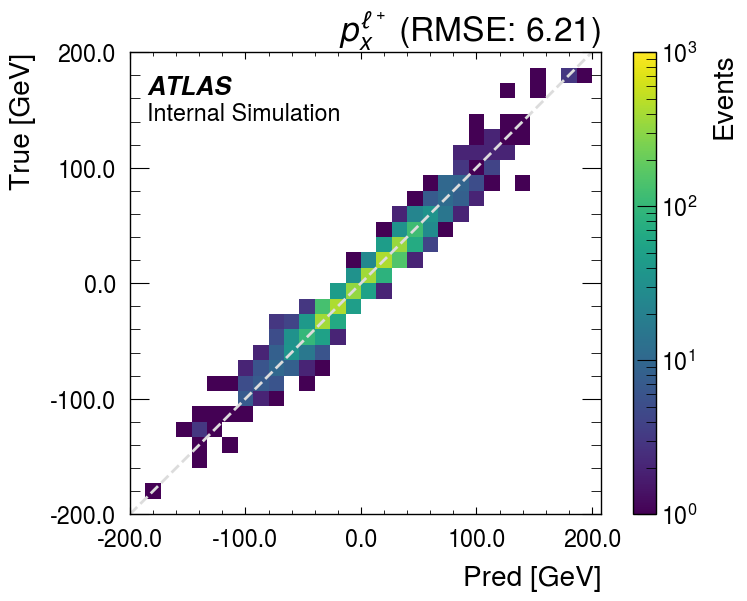

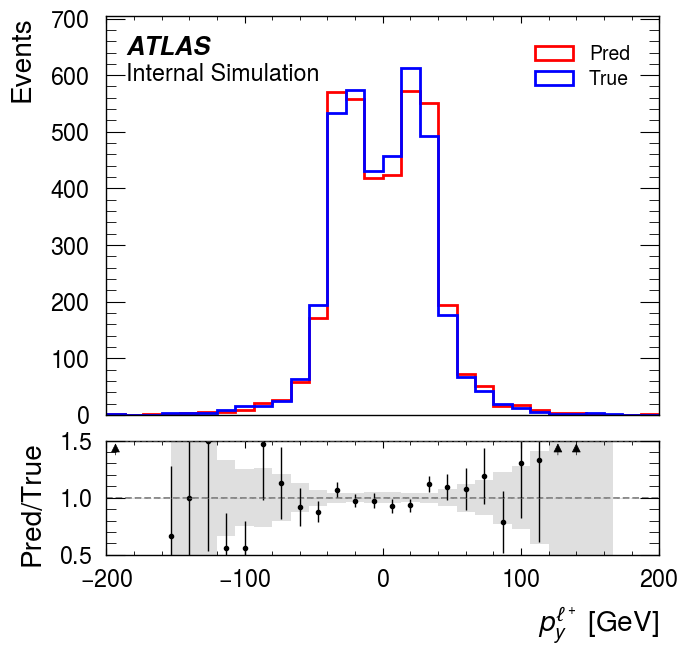

Rel err < 20%: 64.12 %


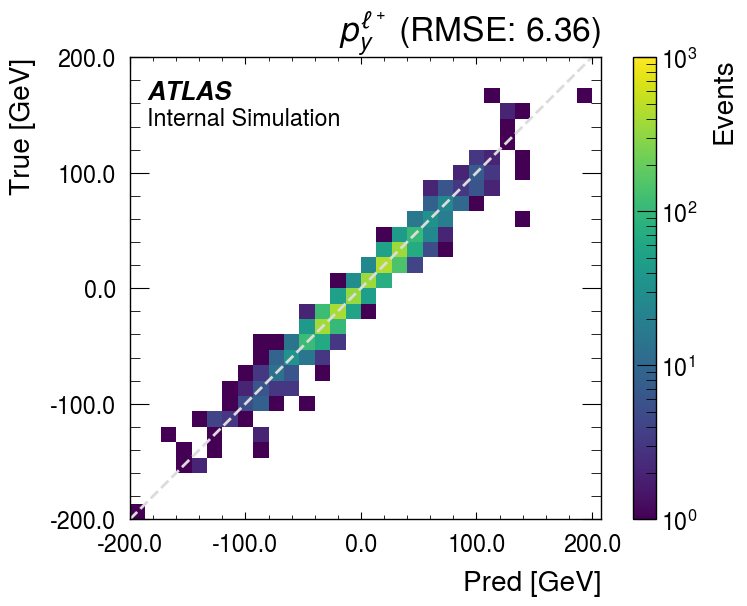

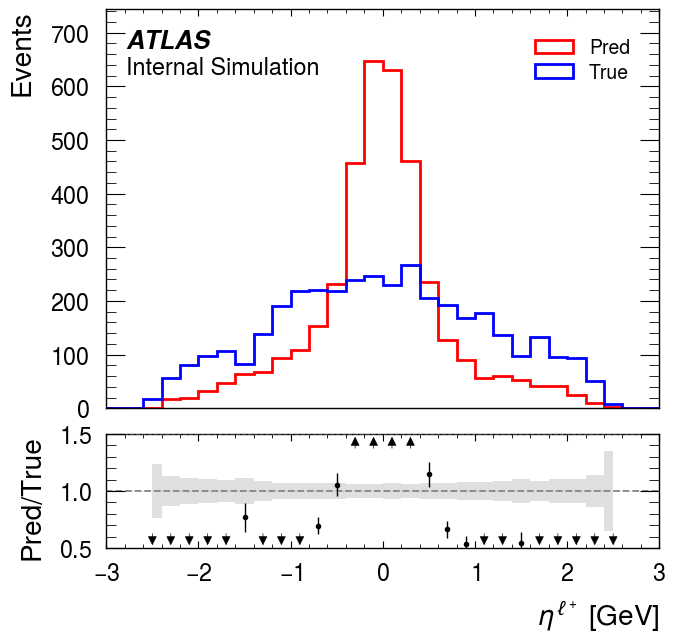

Rel err < 20%: 12.50 %


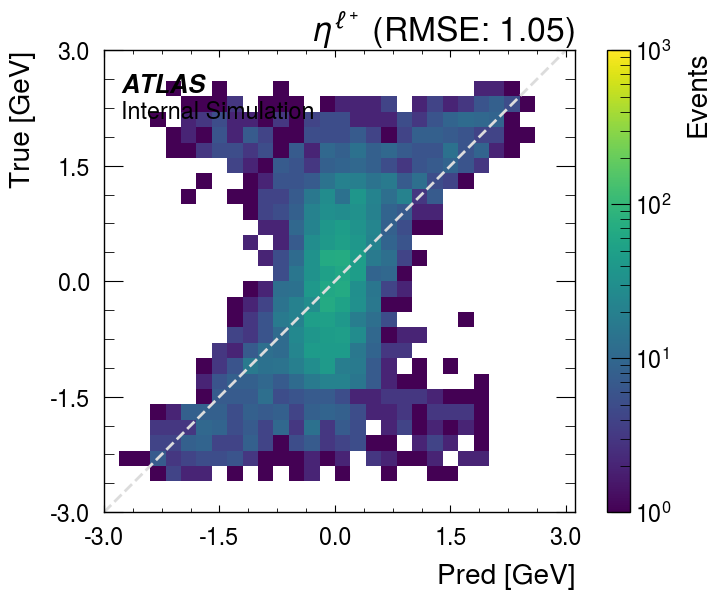

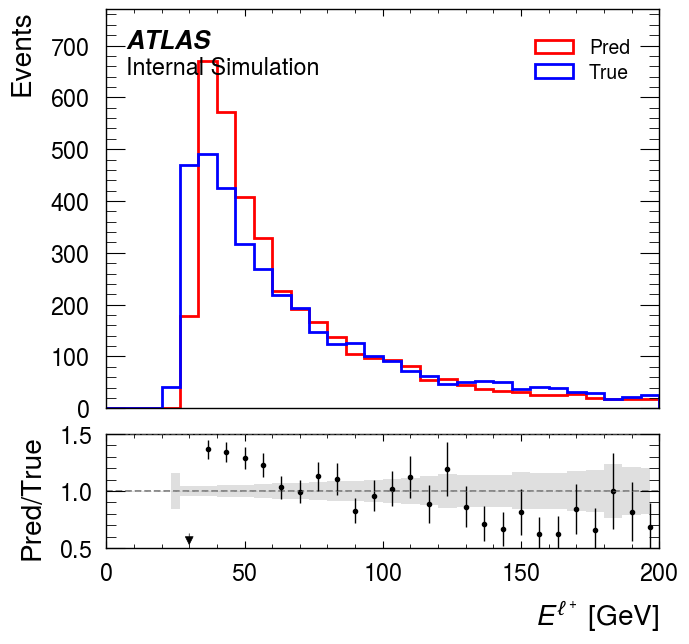

Rel err < 20%: 53.66 %


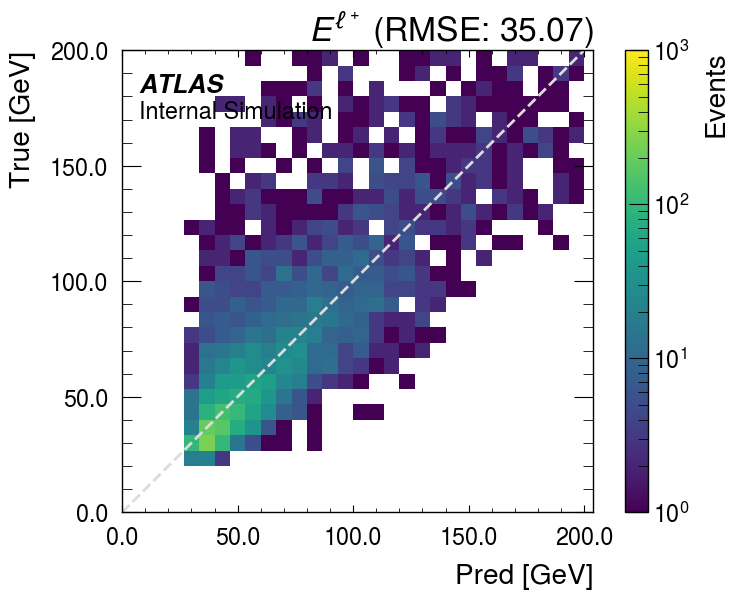

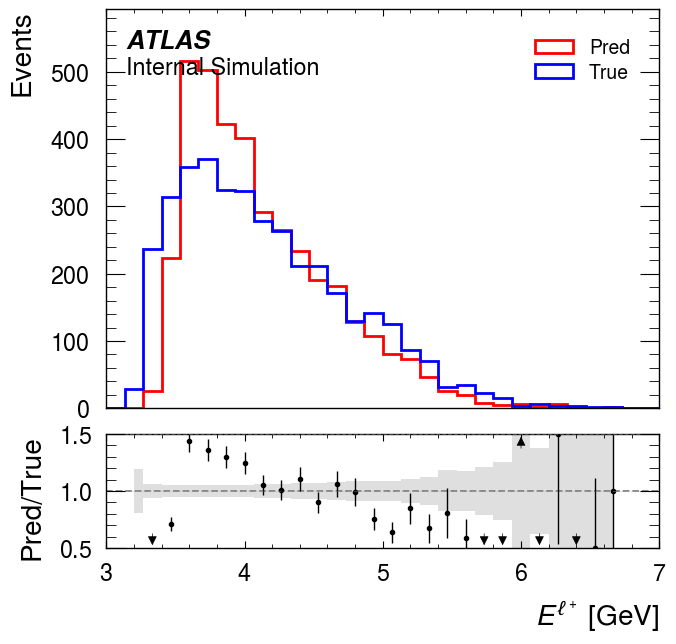

Rel err < 20%: 98.20 %


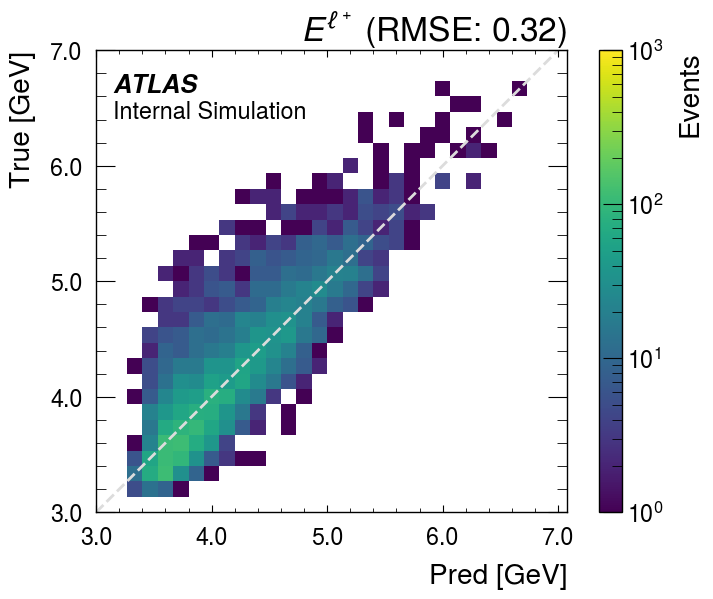

In [17]:
plot_1d_hist(pred_lep0_px, true_lep0_px, "$p^{\ell^+}_x$", bins_edges=np.linspace(-200, 200, 31))
plot_2d_hist(pred_lep0_px, true_lep0_px, "$p^{\ell^+}_x$", bins_edges=np.linspace(-200, 200, 31), log=True)

plot_1d_hist(pred_lep0_py, true_lep0_py, "$p^{\ell^+}_y$", bins_edges=np.linspace(-200, 200, 31))
plot_2d_hist(pred_lep0_py, true_lep0_py, "$p^{\ell^+}_y$", bins_edges=np.linspace(-200, 200, 31), log=True)

plot_1d_hist(pred_lep0_eta, true_lep0_eta, "$\eta^{\ell^+}$", bins_edges=np.linspace(-3, 3, 31))
plot_2d_hist(pred_lep0_eta, true_lep0_eta, "$\eta^{\ell^+}$", bins_edges=np.linspace(-3, 3, 31), log=True)

plot_1d_hist(np.exp(pred_lep0_e), np.exp(true_lep0_e), "$E^{\ell^+}$", bins_edges=np.linspace(0, 200, 31))
plot_2d_hist(np.exp(pred_lep0_e), np.exp(true_lep0_e), "$E^{\ell^+}$", bins_edges=np.linspace(0, 200, 31), log=True)

plot_1d_hist(pred_lep0_e, true_lep0_e, "$E^{\ell^+}$", bins_edges=np.linspace(3, 7, 31))
plot_2d_hist(pred_lep0_e, true_lep0_e, "$E^{\ell^+}$", bins_edges=np.linspace(3, 7, 31), log=True)

In [18]:
pred_l0_theta = predictions[..., 0]
pred_l0_phi = predictions[..., 1]
pred_l1_theta = predictions[..., 2]
pred_l1_phi = predictions[..., 3]

true_l0_theta = true_labels[..., 0]
true_l0_phi = true_labels[..., 1]
true_l1_theta = true_labels[..., 2]
true_l1_phi = true_labels[..., 3]

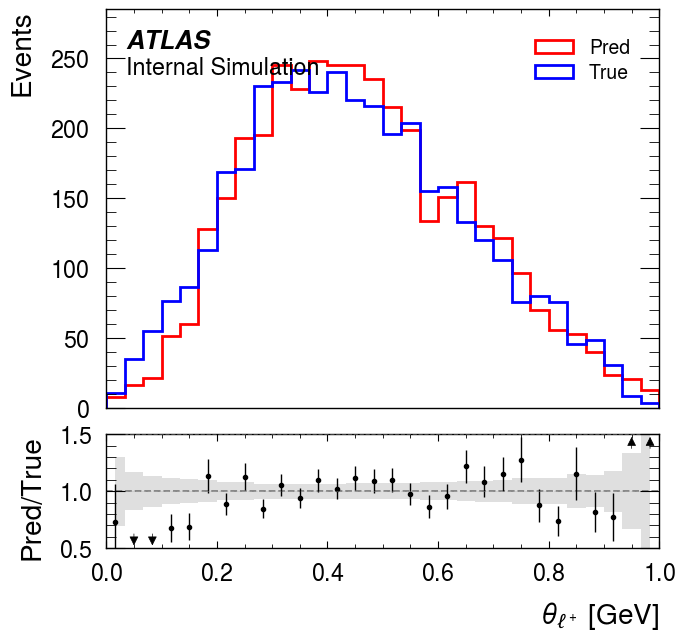

Rel err < 20%: 31.26 %


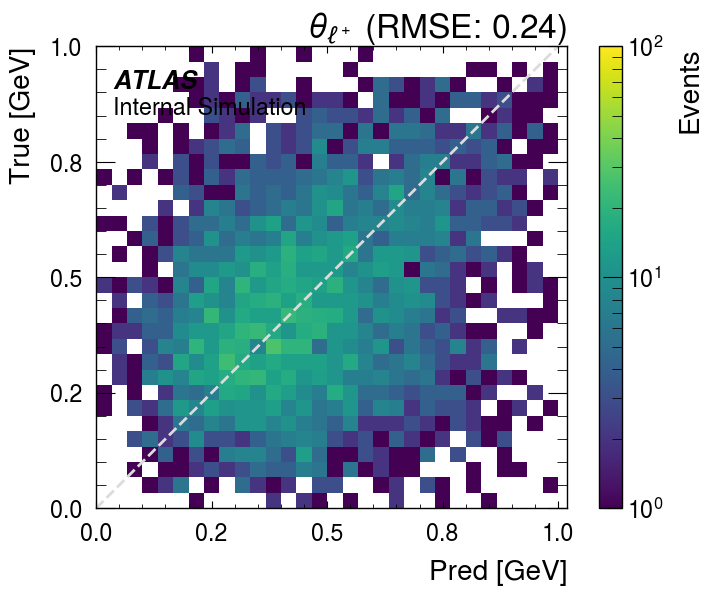

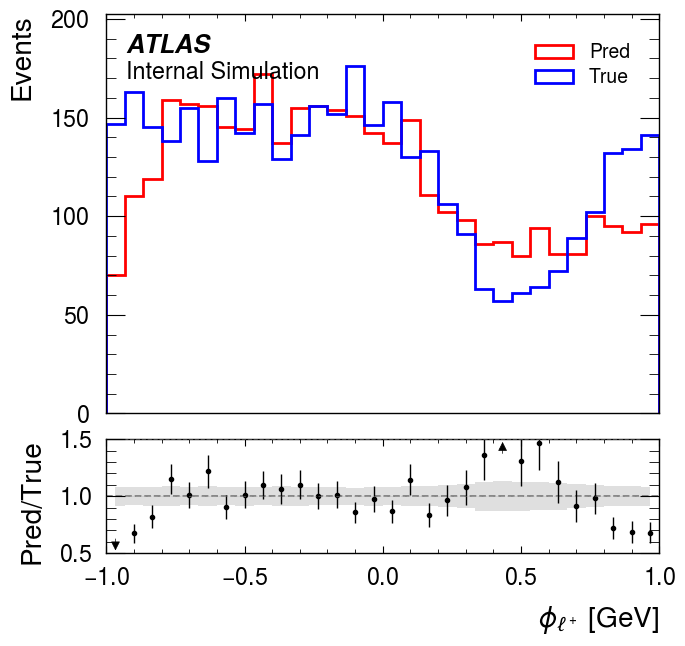

Rel err < 20%: 12.34 %


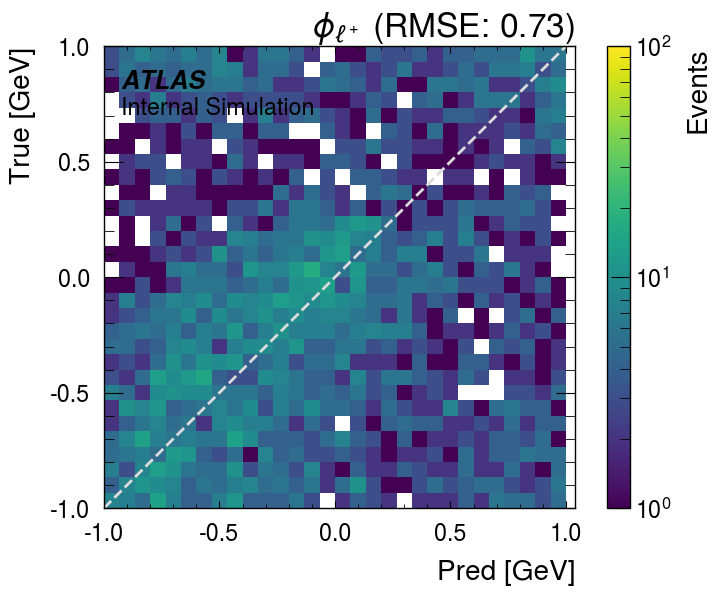

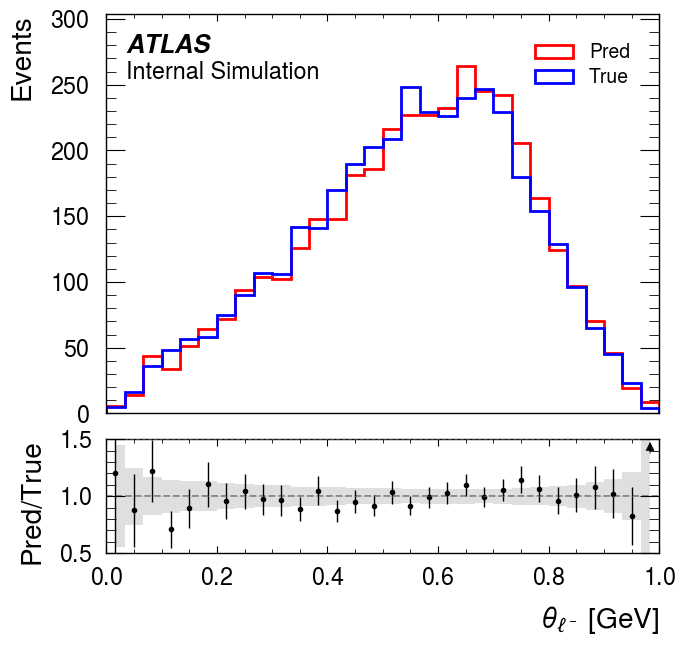

Rel err < 20%: 34.71 %


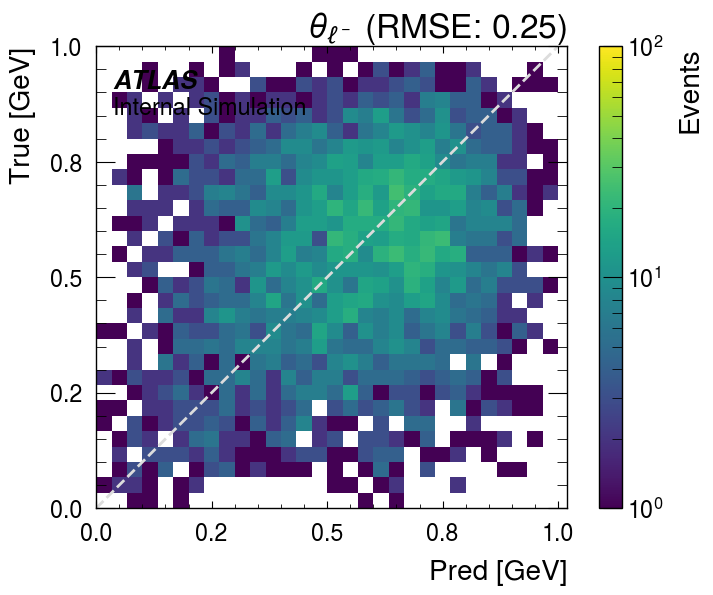

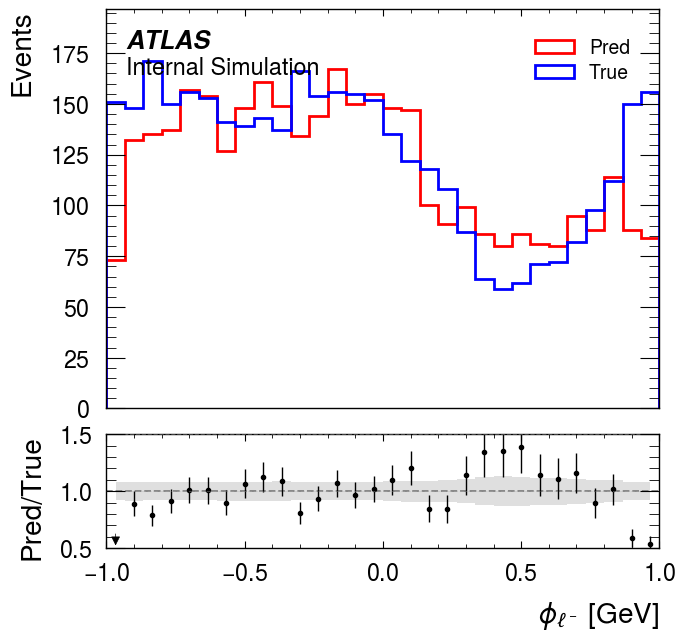

Rel err < 20%: 11.28 %


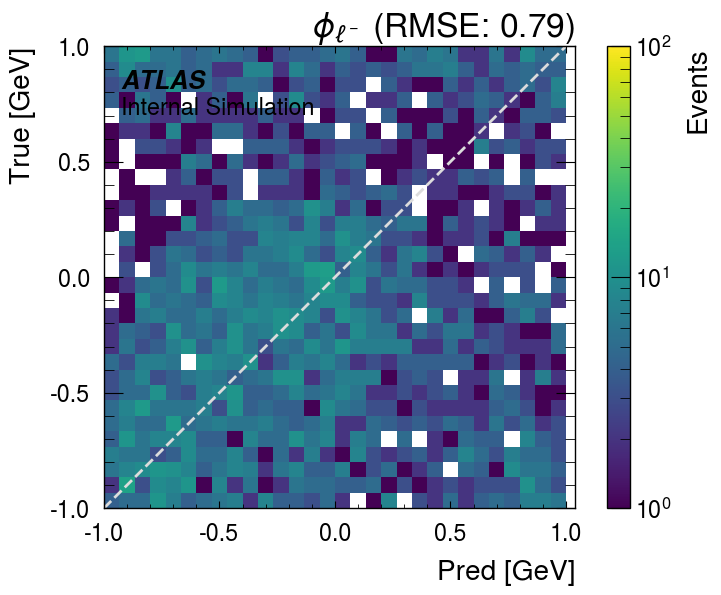

In [19]:
plot_1d_hist(pred_l0_theta, true_l0_theta, "$\\theta_{\ell^+}$", np.linspace(0, 1, 31))
plot_2d_hist(pred_l0_theta, true_l0_theta, "$\\theta_{\ell^+}$", np.linspace(0, 1, 31), log=True, vmax=1e2)

plot_1d_hist(pred_l0_phi, true_l0_phi, "$\\phi_{\ell^+}$", np.linspace(-1, 1, 31))
plot_2d_hist(pred_l0_phi, true_l0_phi, "$\\phi_{\ell^+}$", np.linspace(-1, 1, 31), log=True, vmax=1e2)

plot_1d_hist(pred_l1_theta, true_l1_theta, "$\\theta_{\ell^-}$", np.linspace(0, 1, 31))
plot_2d_hist(pred_l1_theta, true_l1_theta, "$\\theta_{\ell^-}$", np.linspace(0, 1, 31), log=True, vmax=1e2)

plot_1d_hist(pred_l1_phi, true_l1_phi, "$\\phi_{\ell^-}$", np.linspace(-1, 1, 31))
plot_2d_hist(pred_l1_phi, true_l1_phi, "$\\phi_{\ell^-}$", np.linspace(-1, 1, 31), log=True, vmax=1e2)

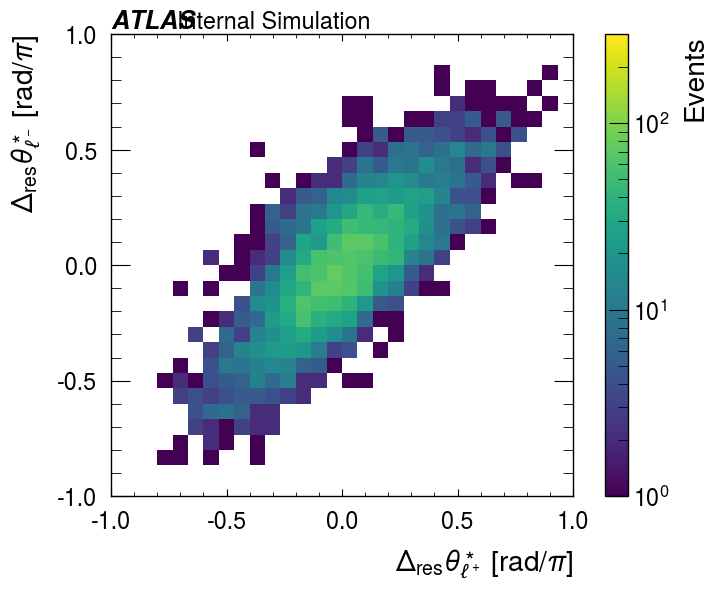

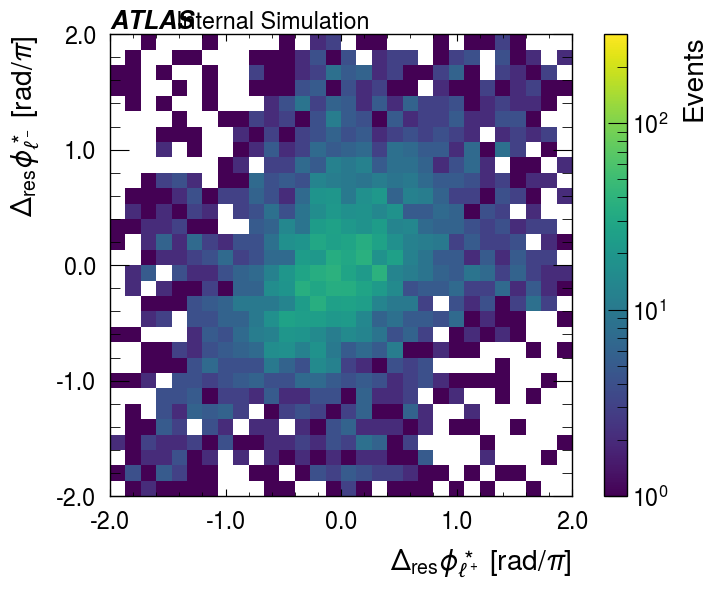

In [20]:
l0_theta_res = pred_l0_theta - true_l0_theta
l1_theta_res = pred_l1_theta - true_l1_theta
plot_2d_res_hist(l0_theta_res, l1_theta_res, name_pos=r"$\theta^\ast_{\ell^+}$", name_neg=r"$\theta^\ast_{\ell^-}$", bins_edges=np.linspace(-1, 1, 31), log=True, unit="rad/$\pi$", color="black", vmax=3e2)

l0_phi_res = pred_l0_phi - true_l0_phi
l1_phi_res = pred_l1_phi - true_l1_phi
plot_2d_res_hist(l0_phi_res, l1_phi_res, name_pos=r"$\phi^\ast_{\ell^+}$", name_neg=r"$\phi^\ast_{\ell^-}$", bins_edges=np.linspace(-2, 2, 31), log=True, unit="rad/$\pi$", color="black", vmax=3e2)